In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [22]:
df = pd.read_csv('cleaned_data.csv')
df.head()

,index,Soilcolor,Ph,Potassium,Phosphorus,Nitrogen,Zinc,Sulphur,Humidity-W,Humidity-Sp,...,Precipitation-W,Precipitation-Sp,Precipitation-Su,Precipitation-Au,Wind_Direction_10m_above_ground,Soil_Moisture_in_top_layer,Cloud_cover_percentage_or_amount,Range_of_wind_speed_at_2m_above_ground,Atmospheric_pressure,Crop
0,0,yellowish brown,5.81,738.231,5.401,0.23,2.976000,13.816,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
1,1,yellowish brown,5.43,606.382,10.478,0.23,3.077000,16.421,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
2,2,brown,5.41,386.580,6.847,0.23,6.611000,16.557,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
3,3,red,5.65,207.086,3.418,0.23,0.460181,16.075,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
4,4,red,5.27,317.357,39.282,0.23,2.743000,12.558,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley


In [23]:
df.columns

Index(['index', 'Soilcolor', 'Ph', 'Potassium', 'Phosphorus', 'Nitrogen',
       'Zinc', 'Sulphur', 'Humidity-W', 'Humidity-Sp', 'Humidity-Su',
       'Humidity-Au', 'Air_Temperature_MAX-W', 'Air_Temperature_MAX-Sp',
       'Air_Temperature_MAX-Su', 'Air_Temperature_MAX-Au',
       'Air_Temperature_MIN-W', 'Air_Temperature_MIN-Sp',
       'Air_Temperature_MIN-Su', 'Air_Temperature_MIN-Au', 'Precipitation-W',
       'Precipitation-Sp', 'Precipitation-Su', 'Precipitation-Au',
       'Wind_Direction_10m_above_ground', 'Soil_Moisture_in_top_layer',
       'Cloud_cover_percentage_or_amount',
       'Range_of_wind_speed_at_2m_above_ground', 'Atmospheric_pressure',
       'Crop'],
      dtype='object')

In [24]:
df.head()

,index,Soilcolor,Ph,Potassium,Phosphorus,Nitrogen,Zinc,Sulphur,Humidity-W,Humidity-Sp,...,Precipitation-W,Precipitation-Sp,Precipitation-Su,Precipitation-Au,Wind_Direction_10m_above_ground,Soil_Moisture_in_top_layer,Cloud_cover_percentage_or_amount,Range_of_wind_speed_at_2m_above_ground,Atmospheric_pressure,Crop
0,0,yellowish brown,5.81,738.231,5.401,0.23,2.976000,13.816,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
1,1,yellowish brown,5.43,606.382,10.478,0.23,3.077000,16.421,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
2,2,brown,5.41,386.580,6.847,0.23,6.611000,16.557,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
3,3,red,5.65,207.086,3.418,0.23,0.460181,16.075,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
4,4,red,5.27,317.357,39.282,0.23,2.743000,12.558,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley


In [26]:
df.to_csv('cropRecommendation.csv',index=False)

In [27]:
df.isna().sum()

index                                     0
Soilcolor                                 0
Ph                                        0
Potassium                                 0
Phosphorus                                0
Nitrogen                                  0
Zinc                                      0
Sulphur                                   0
Humidity-W                                0
Humidity-Sp                               0
Humidity-Su                               0
Humidity-Au                               0
Air_Temperature_MAX-W                     0
Air_Temperature_MAX-Sp                    0
Air_Temperature_MAX-Su                    0
Air_Temperature_MAX-Au                    0
Air_Temperature_MIN-W                     0
Air_Temperature_MIN-Sp                    0
Air_Temperature_MIN-Su                    0
Air_Temperature_MIN-Au                    0
Precipitation-W                           0
Precipitation-Sp                          0
Precipitation-Su                

In [28]:
df.columns

Index(['index', 'Soilcolor', 'Ph', 'Potassium', 'Phosphorus', 'Nitrogen',
       'Zinc', 'Sulphur', 'Humidity-W', 'Humidity-Sp', 'Humidity-Su',
       'Humidity-Au', 'Air_Temperature_MAX-W', 'Air_Temperature_MAX-Sp',
       'Air_Temperature_MAX-Su', 'Air_Temperature_MAX-Au',
       'Air_Temperature_MIN-W', 'Air_Temperature_MIN-Sp',
       'Air_Temperature_MIN-Su', 'Air_Temperature_MIN-Au', 'Precipitation-W',
       'Precipitation-Sp', 'Precipitation-Su', 'Precipitation-Au',
       'Wind_Direction_10m_above_ground', 'Soil_Moisture_in_top_layer',
       'Cloud_cover_percentage_or_amount',
       'Range_of_wind_speed_at_2m_above_ground', 'Atmospheric_pressure',
       'Crop'],
      dtype='object')

In [29]:
crops_features = df.drop(columns=['Soilcolor','Crop'], axis=1)
# Build statistical outlier detection function

# Separate dataset features for EDA

def detect_outliers(dataset_features):
    """
    Detect outliers in the dataset using the Interquartile Range (IQR) method.
   
    Args:
        dataset_features (pd.DataFrame): Input DataFrame containing numerical features to analyze
       
    Returns:
    pd.DataFrame: DataFrame containing for each feature:
            - Lower Bound: Q1 - 1.5*IQR threshold for outliers
            - Upper Bound: Q3 + 1.5*IQR threshold for outliers 
            - Outliers Count: Number of values outside the bounds      
    Notes:
        - Uses the standard 1.5*IQR rule: points below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are considered outliers
    """
    outliers = pd.DataFrame(index=crops_features.columns)
    # Calculate quantiles
    Q1 = dataset_features.quantile(0.25)
    Q3 = dataset_features.quantile(0.75)
    # Calculate IQR range
    IQR = Q3 - Q1
    # Define upper and lower bounds 
    outliers['Lower Bound'] = Q1 - 1.5*IQR
    outliers['Upper Bound'] = Q3 + 1.5*IQR
    # 
    outliers['Outliers Count'] = [
        ((dataset_features[col] < outliers.loc[col, 'Lower Bound']) | 
         (dataset_features[col] > outliers.loc[col, 'Upper Bound'])).sum()
         for col in dataset_features.columns
    ]
    return outliers

# Print the result of detect_outliers
print("\nOutlier Analysis:")
print(detect_outliers(crops_features), '\n')


Outlier Analysis:
                                        Lower Bound  Upper Bound  \
index                                  -1933.000000  5799.000000   
Ph                                         4.175000     7.415000   
Potassium                               -130.000000   726.000000   
Phosphorus                                -6.880000    16.800000   
Nitrogen                                  -0.017000     0.378200   
Zinc                                      -0.340000     3.500000   
Sulphur                                   -3.030750    24.531250   
Humidity-W                                 6.468333    10.375000   
Humidity-Sp                                6.788333    11.095000   
Humidity-Su                                9.320000    14.946667   
Humidity-Au                                8.225000    13.358333   
Air_Temperature_MAX-W                     20.846667    32.473333   
Air_Temperature_MAX-Sp                    25.440000    34.586667   
Air_Temperature_MAX-Su       

In [30]:
custom_palette = ['#2c5530', '#739e82', '#f3ffb6', '#d38b5d', '#99621e']

%config InlineBackend.figure_format='retina'
custom_params = {'grid.alpha': 0.5, 
                 'axes.titlesize': 12, 
                 #'figure.figsize': (10, 5),
                 'figure.titlesize': 14,
                 'axes.spines.top': False, # Remove the top and right spines
                 'axes.spines.right': False, # Remove the top and right spines
                 'axes.labelsize': 10,
                 'xtick.labelsize': 8,
                 'ytick.labelsize': 8,
                }

sns.set_theme(context='paper', style='whitegrid', palette='BrBG', font='sans-serif', font_scale=1, color_codes=True, 
              rc=custom_params)


In [31]:
# Create correlation matrix
correlation_matrix = df.drop(columns=['Soilcolor','Crop'], axis=1).corr()

# Visualize correlations
fig, axes = plt.subplots(figsize=(50,50), dpi=100)
sns.heatmap(correlation_matrix, annot=True, cmap=custom_palette, center=0)
plt.title('Feature Correlation Matrix')
# Adjust label sizes
plt.xticks(fontsize=8)  # Smaller x-axis labels
plt.yticks(fontsize=8)  # Smaller y-axis labels
plt.title('Feature Correlation Matrix', fontsize=10)  # Smaller title
plt.show()

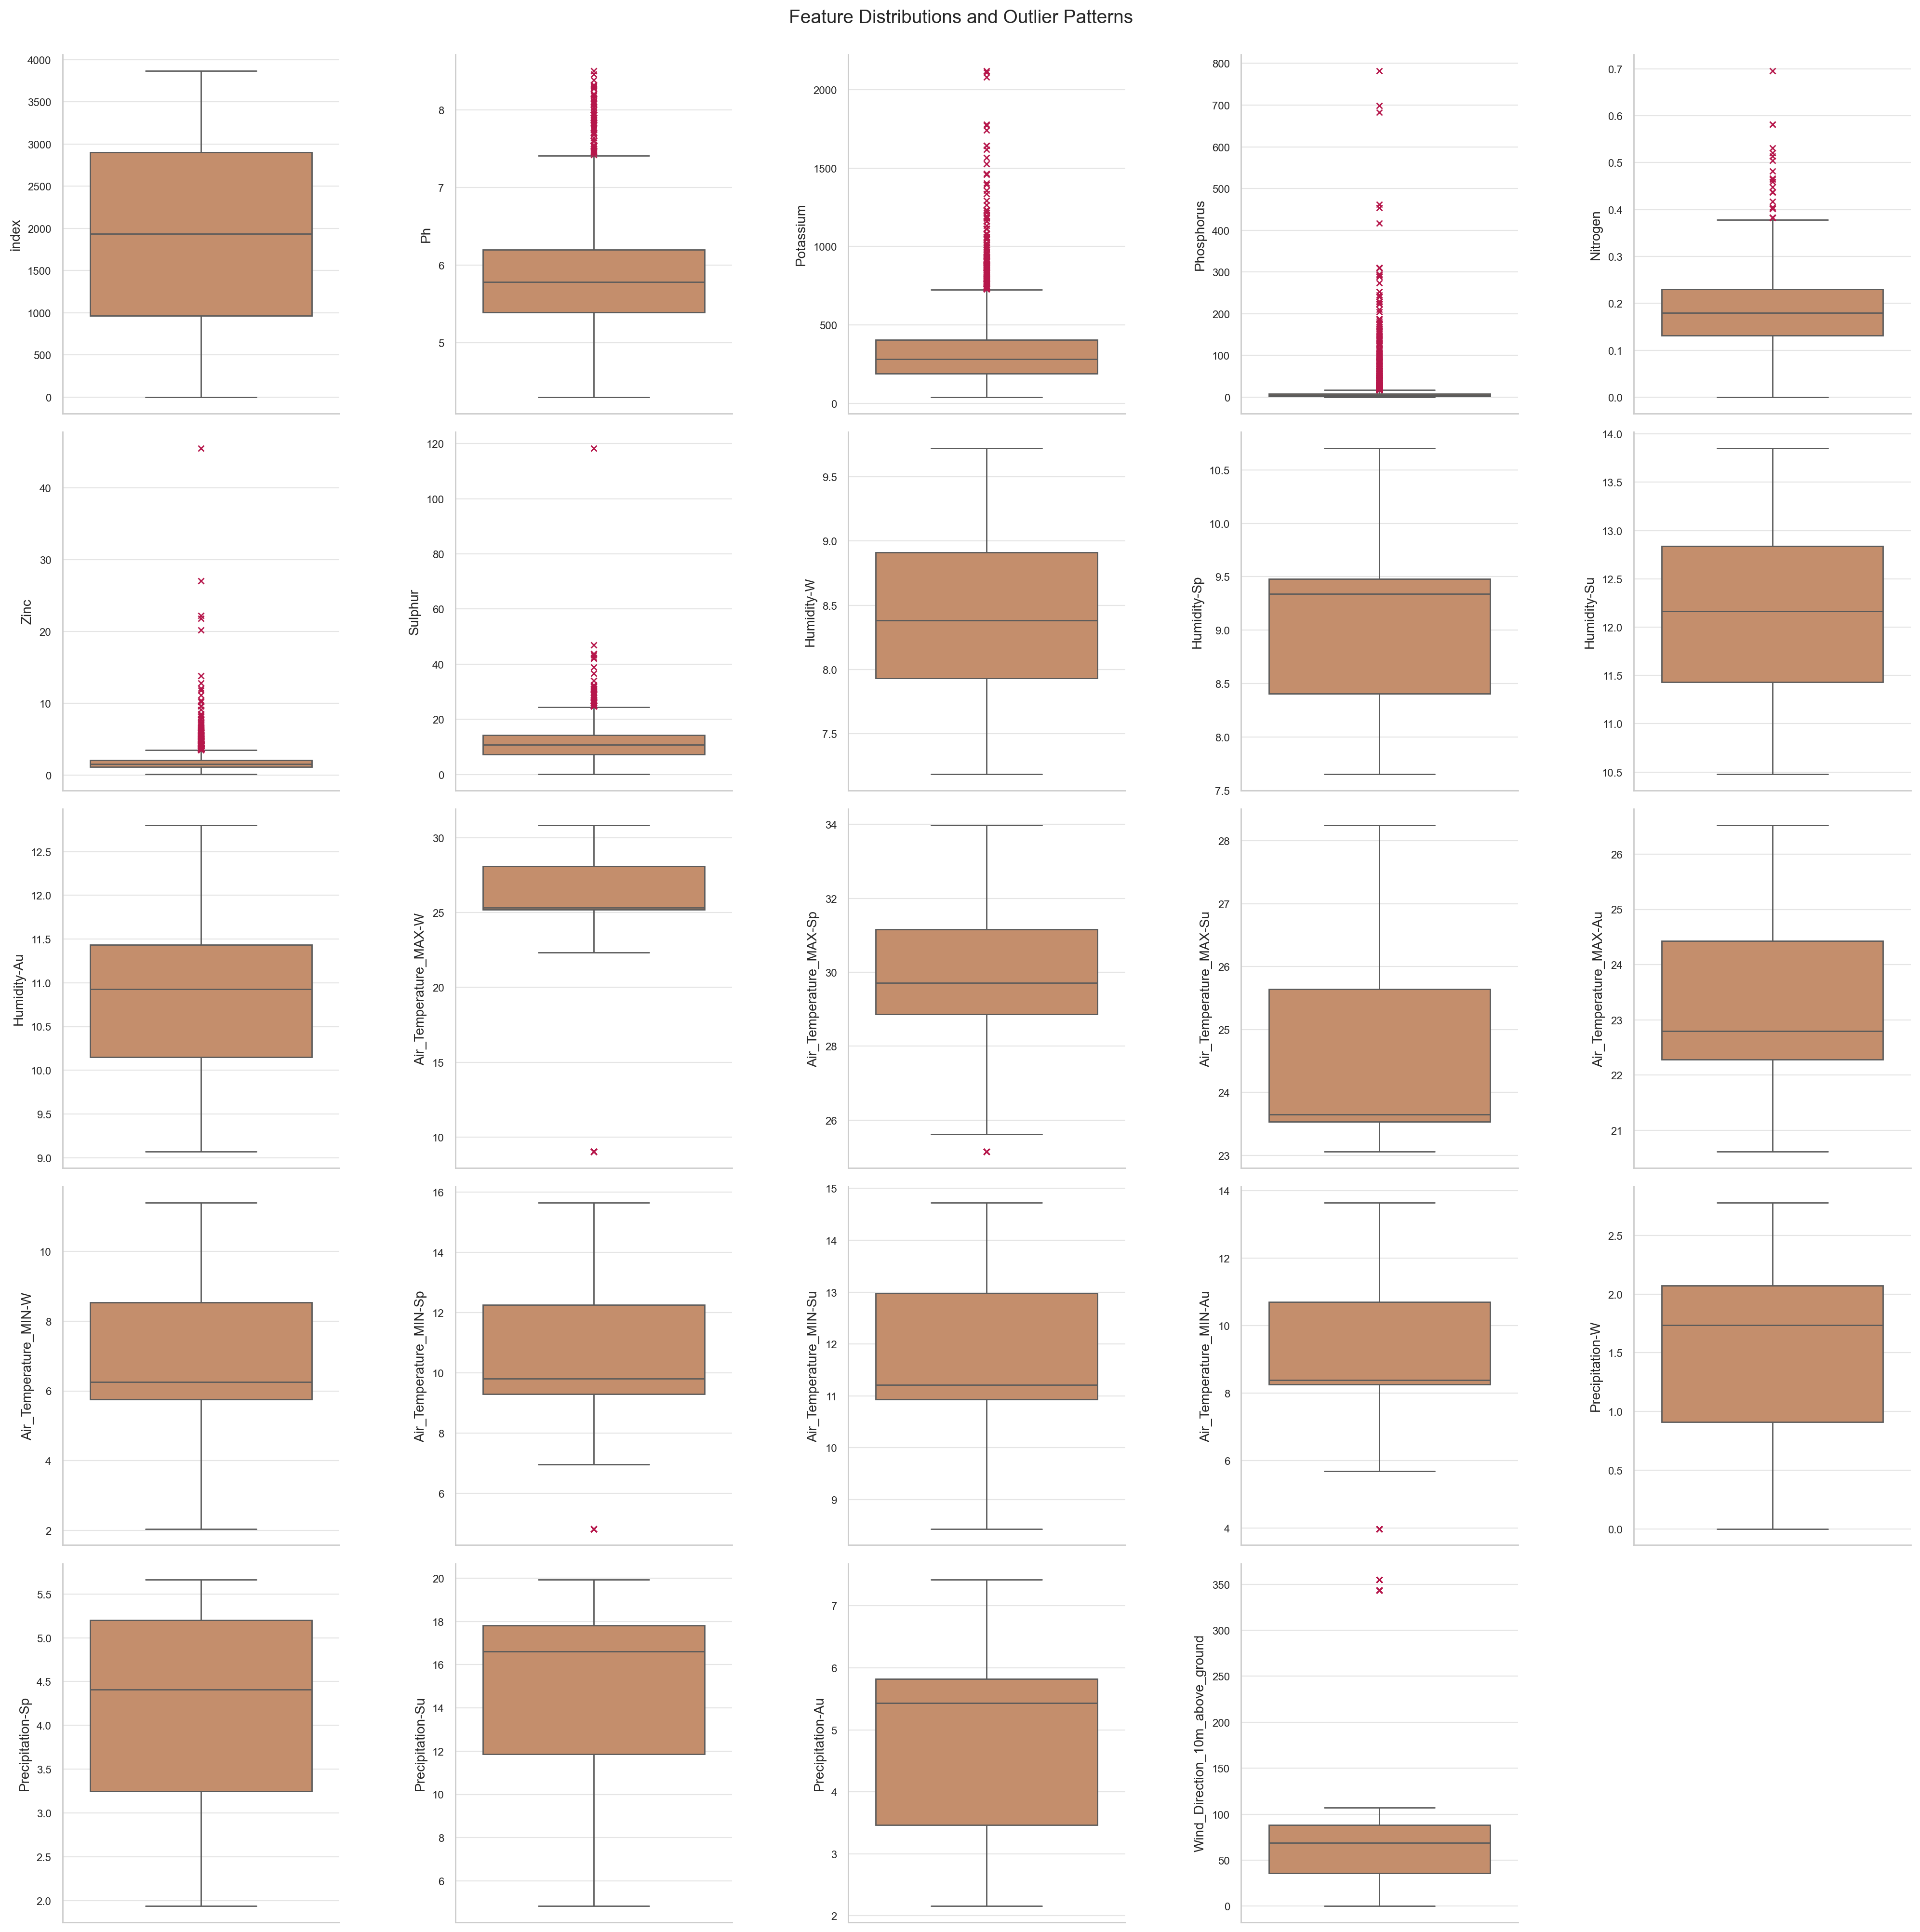

In [32]:
# Visualize distributions
fig, axes = plt.subplots(5, 5, figsize=(20,20))

for ax, col in zip(axes.flat[:len(crops_features.columns)], crops_features.columns): # .flat converts a multi-dimensional array into a 1D array.
    # Create a boxplot
    sns.boxplot(data=crops_features, y=col, ax=ax, color=custom_palette[3], flierprops={'markerfacecolor': '#b6174b', 
                                                                                       'markeredgecolor': '#b6174b', 
                                                                                       'marker': 'x',
                                                                                       'markersize': 4})
axes.flat[-1].remove()
# Add figure title
fig.suptitle('Feature Distributions and Outlier Patterns', y=1)
plt.tight_layout(h_pad=1, w_pad=5)  # Increase spacing between subplots
plt.show()
                 

In [33]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encoder_soil = LabelEncoder()
label_encoder_label = LabelEncoder()
df['Soilcolor'] = label_encoder_soil.fit_transform(df['Soilcolor'])
df['Crop'] = label_encoder_label.fit_transform(df['Crop'])

In [34]:
X = df.drop(columns=['Crop'])
y = df['Crop']

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [38]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
def evaluate_model(model, X_test, y_test):
    # Predicting using the provided model
    y_pred = model.predict(X_test)
    
    # Calculating accuracy
    score = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy on Test Data = {score*100:.2f}%")
    
    # Printing classification report
    print(f"Classification Report {model} :\n{classification_report(y_test, y_pred)}")
    
    # Calculating and printing confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cf_matrix}")
    
    # Plotting the confusion matrix
    fig, ax = plt.subplots(figsize=(6,6))
    sns.heatmap(cf_matrix, annot=True, cmap='coolwarm')
    fig.suptitle("Confusion Matrix", color="orange", fontsize=16)
    ax.set(xlabel="Predicted Label", ylabel="Actual Label")
    plt.show()

In [59]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_predrandom = clf.predict(X_test)

# Evaluating the model
score_RandomForest = accuracy_score(y_test, y_predrandom)
print(f"Model Accuracy on Test Data = {score_RandomForest*100:.2f}%")

Model Accuracy on Test Data = 92.38%


Model Accuracy on Test Data = 92.38%
Classification Report RandomForestClassifier(random_state=42) :
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       121
           1       0.78      0.76      0.77        41
           2       0.88      0.93      0.90        15
           3       0.00      0.00      0.00         3
           4       0.84      0.94      0.89       141
           5       0.75      0.40      0.52        15
           6       0.71      0.67      0.69        15
           7       0.40      0.33      0.36         6
           8       0.67      0.44      0.53         9
           9       0.45      0.36      0.40        14
          10       0.99      1.00      1.00       254
          11       1.00      1.00      1.00       140

    accuracy                           0.92       774
   macro avg       0.70      0.65      0.67       774
weighted avg       0.92      0.92      0.92       774

Confusion Matrix:
[[117   1   1 

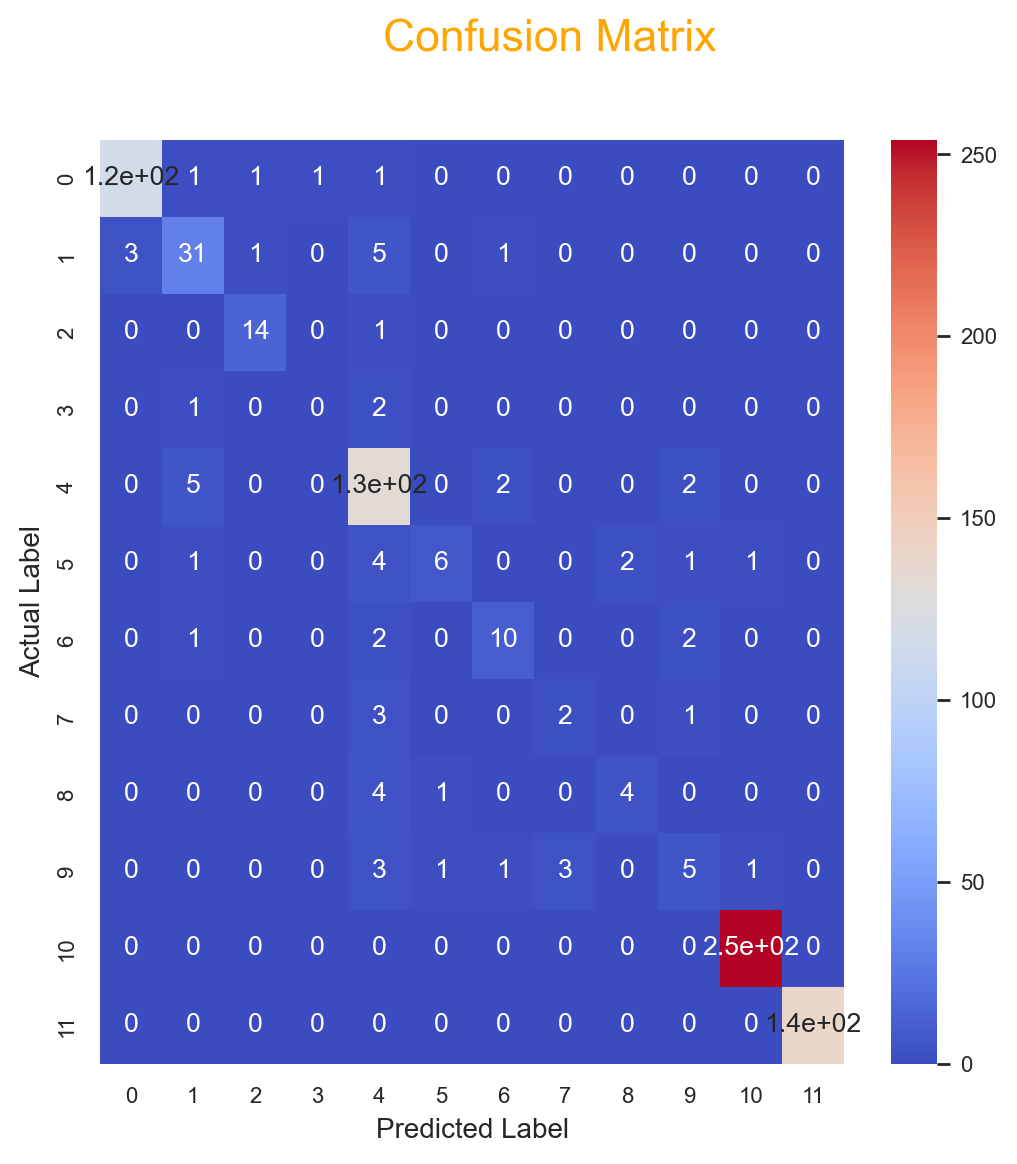

In [60]:
evaluate_model(clf,X_test,y_test)

In [61]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_predxgb = xgb.predict(X_test)
score_XGB = accuracy_score(y_test, y_predxgb)
print(f"Model Accuracy on Test Data = {score_XGB*100:.2f}%")

Model Accuracy on Test Data = 99.35%


Model Accuracy on Test Data = 99.35%
Classification Report XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...) :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00        41
         

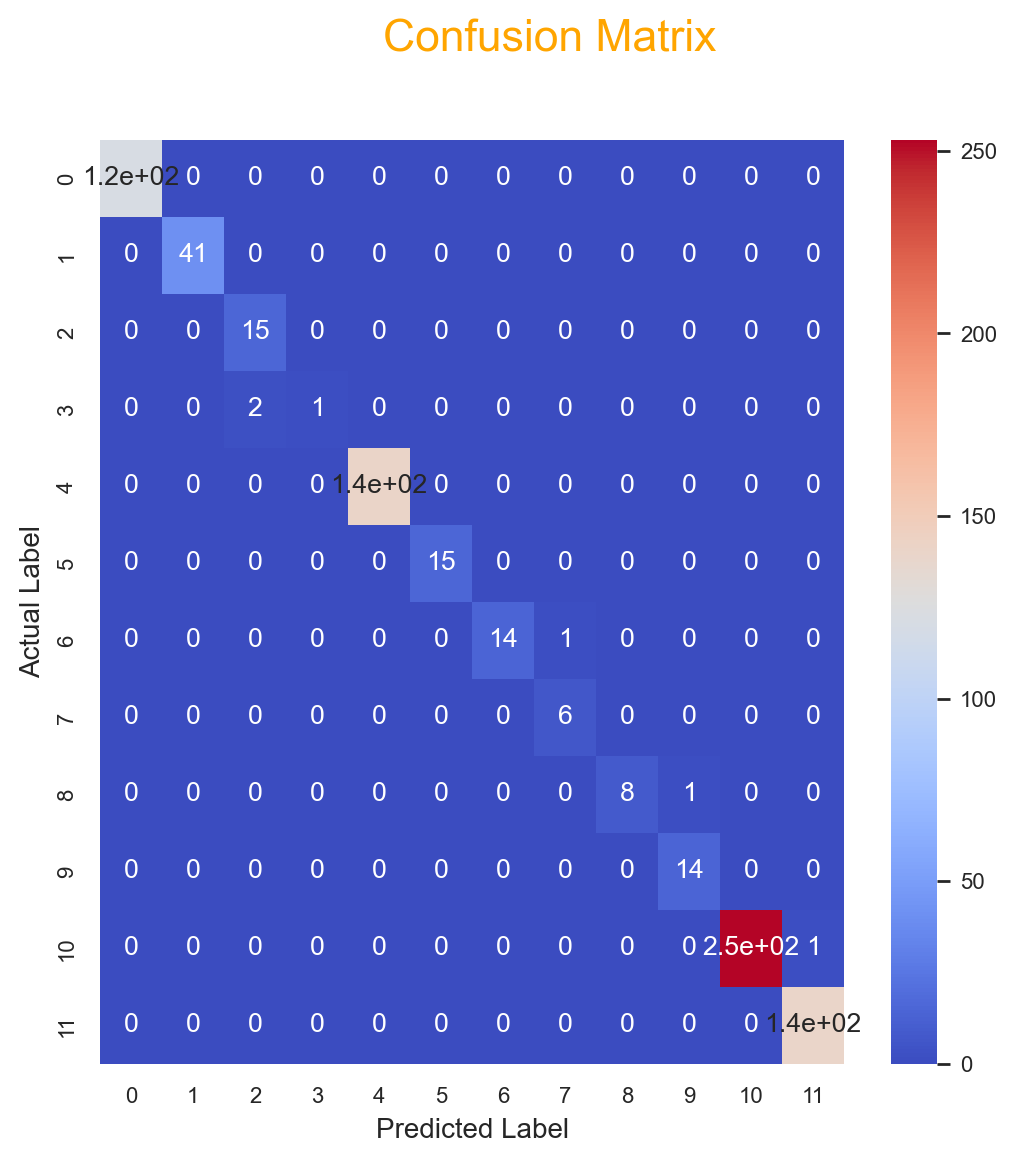

In [62]:
evaluate_model(xgb ,X_test, y_test)

In [63]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier()
KNN.fit(X_train, y_train)
y_predKNN = KNN.predict(X_test)
score_KNN = accuracy_score(y_test, y_predKNN)
print(f"Model Accuracy on Test Data = {score_KNN*100:.2f}%")

Model Accuracy on Test Data = 77.39%


Model Accuracy on Test Data = 77.39%
Classification Report KNeighborsClassifier() :
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       121
           1       0.37      0.37      0.37        41
           2       0.67      0.40      0.50        15
           3       0.00      0.00      0.00         3
           4       0.69      0.84      0.76       141
           5       1.00      0.07      0.12        15
           6       0.56      0.33      0.42        15
           7       0.00      0.00      0.00         6
           8       0.00      0.00      0.00         9
           9       0.14      0.07      0.10        14
          10       0.84      0.96      0.90       254
          11       0.94      0.82      0.88       140

    accuracy                           0.77       774
   macro avg       0.50      0.39      0.40       774
weighted avg       0.76      0.77      0.75       774

Confusion Matrix:
[[ 94  12   2   0  10   0   0  

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


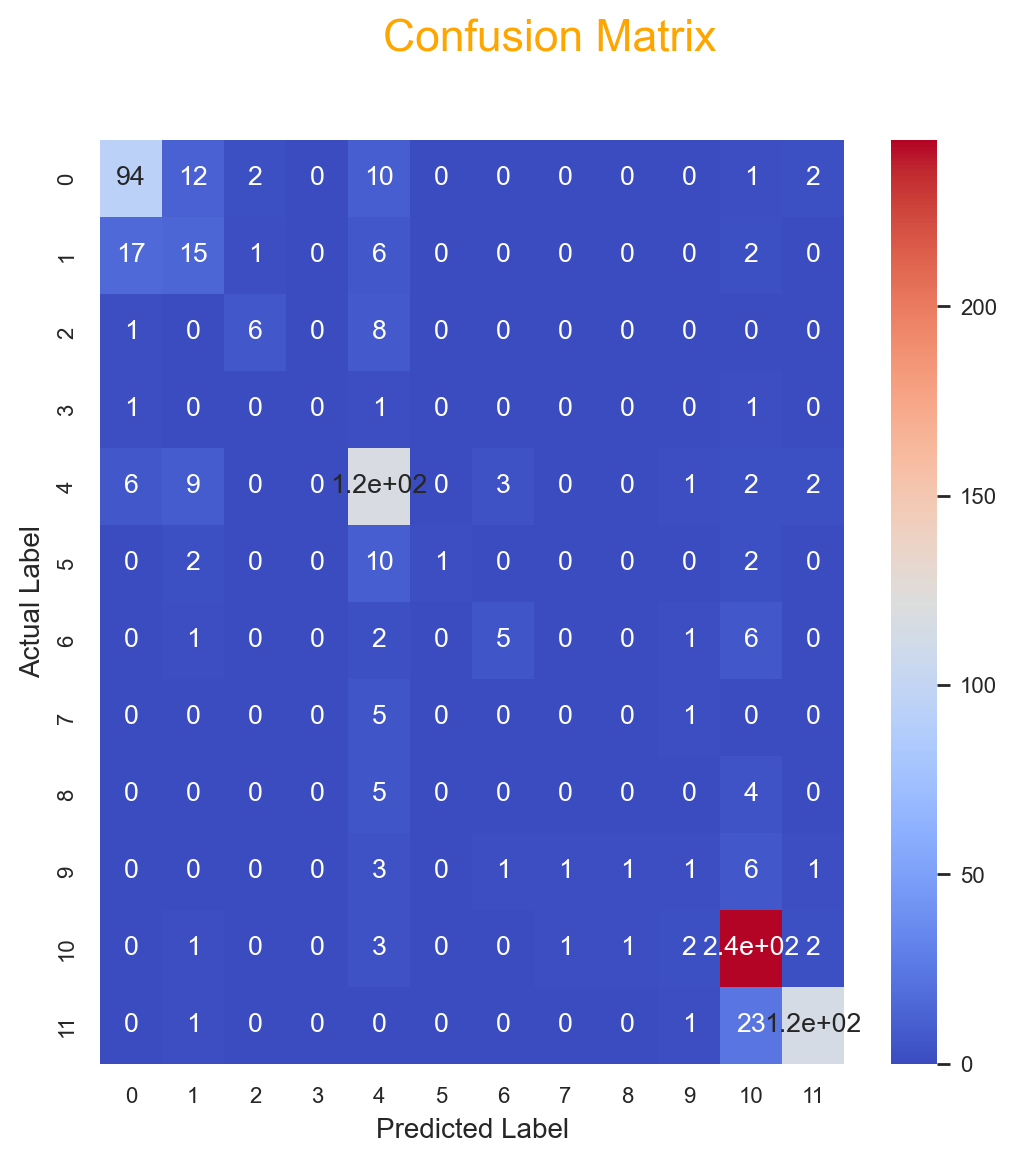

In [64]:
evaluate_model(KNN, X_test, y_test)

In [65]:
score_RandomForest, score_XGB, score_KNN

(0.9237726098191215, 0.9935400516795866, 0.7739018087855297)

/var/folders/lv/cmxrpk6x201g31179k2jw81w0000gn/T/ipykernel_1726/3556050448.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=data, palette='viridis')


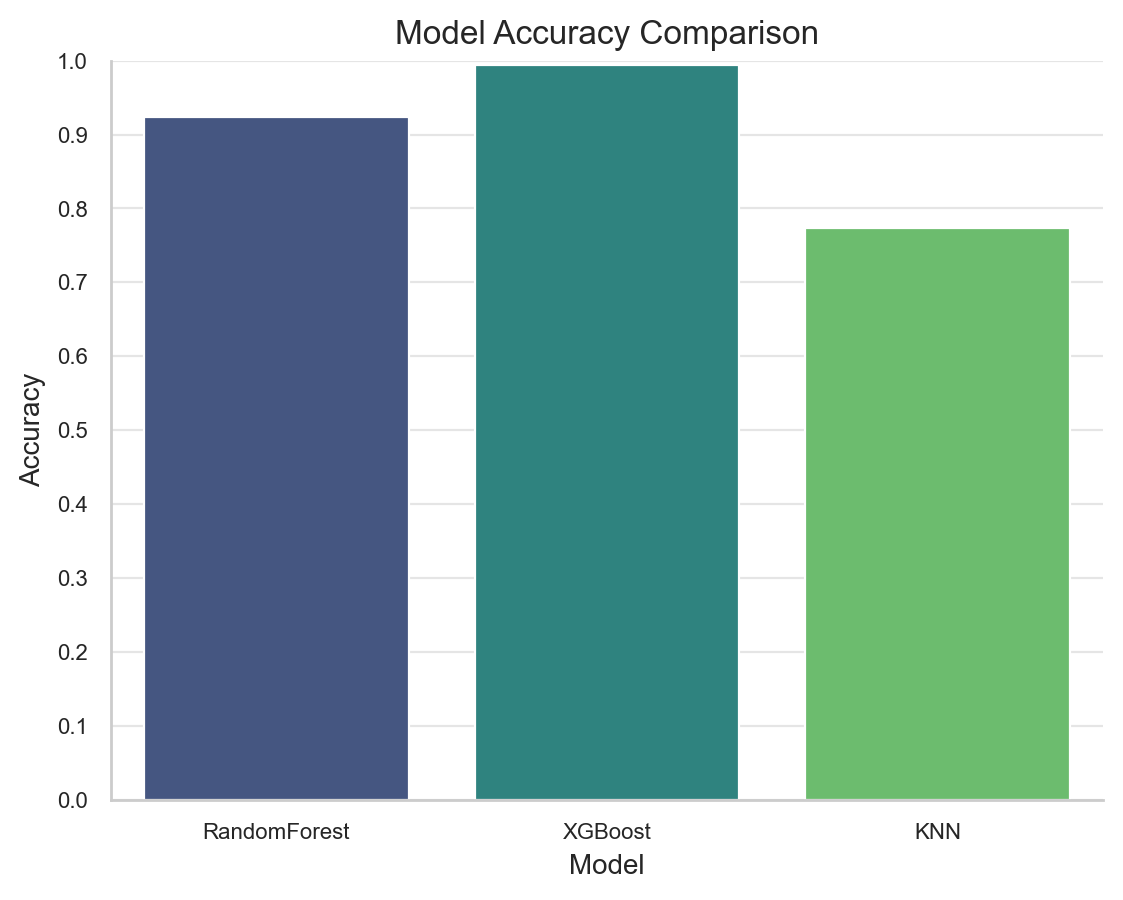

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Data for plotting
models = ['RandomForest', 'XGBoost', 'KNN']
scores = [score_RandomForest, score_XGB, score_KNN]  # Assuming these variables hold accuracy scores between 0 and 1

# Create a DataFrame for Seaborn
data = pd.DataFrame({'Model': models, 'Accuracy': scores})

# Plot
sns.barplot(x='Model', y='Accuracy', data=data, palette='viridis')
plt.ylim(0, 1)  # Set y-axis limits from 0 to 1
plt.yticks([i * 0.1 for i in range(11)])  # Set y-axis ticks at intervals of 0.1
plt.title('Model Accuracy Comparison')
plt.show()


In [131]:
import joblib

# Save the trained Random Forest model
joblib.dump(xgb, 'random_forest_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the label encoder for the target variable
joblib.dump(label_encoder_label, 'label_encoder.pkl')

print("Model, scaler, and label encoder saved successfully!")
# Save the label encoder for 'Soilcolor'
joblib.dump(label_encoder_soil, 'soilcolor_encoder.pkl')
print("Soilcolor encoder saved successfully!")


Model, scaler, and label encoder saved successfully!
Soilcolor encoder saved successfully!


In [135]:
# Get row 456 as a list
df.iloc[456].tolist()

[456.0,
 1.0,
 5.2,
 291.0,
 5.0,
 0.1815,
 1.5,
 8.0,
 7.586666667,
 8.136666667,
 11.43,
 10.15,
 26.32666667,
 28.97,
 24.37666667,
 22.67333333,
 7.513333333,
 11.38333333,
 11.81,
 10.08666667,
 0.91,
 2.266666667,
 11.76666667,
 2.96,
 88.31,
 0.63,
 59.11,
 6.01,
 77.15,
 0.0]

In [27]:
# Load the saved model, scaler, and label encoders
import joblib
import pandas as pd

# Load saved files
loaded_model = joblib.load('random_forest_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_label_encoder_label = joblib.load('label_encoder.pkl')
loaded_label_encoder_soil = joblib.load('soilcolor_encoder.pkl')

# Example: New data for inference (ensure all feature columns are included)
new_data = {
    'index': [0],  # Dummy ID (not used for prediction, but included if required)
    'Soilcolor': ['red'],  # Categorical column
    'Ph': [6.5],  # Numerical column
    'Potassium': [120],  # Numerical column
    'Phosphorus': [30],  # Numerical column
    'Nitrogen': [60],  # Numerical column
    'Zinc': [1.5],  # Numerical column
    'Sulphur': [12],  # Numerical column
    'Humidity-W': [0.75],  # Numerical column
    'Humidity-Sp': [0.65],  # Numerical column
    'Humidity-Su': [0.55],  # Numerical column
    'Humidity-Au': [0.45],  # Numerical column
    'Air_Temperature_MAX-W': [25],  # Numerical column
    'Air_Temperature_MAX-Sp': [22],  # Numerical column
    'Air_Temperature_MAX-Su': [30],  # Numerical column
    'Air_Temperature_MAX-Au': [20],  # Numerical column
    'Air_Temperature_MIN-W': [10],  # Numerical column
    'Air_Temperature_MIN-Sp': [8],  # Numerical column
    'Air_Temperature_MIN-Su': [15],  # Numerical column
    'Air_Temperature_MIN-Au': [5],  # Numerical column
    'Precipitation-W': [100],  # Numerical column
    'Precipitation-Sp': [80],  # Numerical column
    'Precipitation-Su': [60],  # Numerical column
    'Precipitation-Au': [90],  # Numerical column
    'Wind_Direction_10m_above_ground': [270],  # Numerical column
    'Soil_Moisture_in_top_layer': [0.3],  # Numerical column
    'Cloud_cover_percentage_or_amount': [0.5],  # Numerical column
    'Range_of_wind_speed_at_2m_above_ground': [5],  # Numerical column
    'Atmospheric_pressure': [1013],  # Numerical column
}

# Convert new data to a DataFrame
new_data_df = pd.DataFrame(new_data)
# Encode the 'Soilcolor' column using the saved encoder
new_data_df['Soilcolor'] = loaded_label_encoder_soil.transform(new_data_df['Soilcolor'])

# Scale the features using the saved scaler
new_data_scaled = loaded_scaler.transform(new_data_df)

# Predict the crop label using the saved model
predicted_label_encoded = loaded_model.predict(new_data_scaled)

# Decode the predicted label to a human-readable form
predicted_label = loaded_label_encoder_label.inverse_transform(predicted_label_encoded)

print("Predicted Crop:", predicted_label[0])


Predicted Crop: Barley


In [140]:
# Load the saved model, scaler, and label encoders
import joblib
import pandas as pd

# Load saved files
loaded_model = joblib.load('random_forest_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_label_encoder_label = joblib.load('label_encoder.pkl')
loaded_label_encoder_soil = joblib.load('soilcolor_encoder.pkl')

# Provided feature values
feature_values = [0, 'brown', 5.2, 291.0, 5.0, 0.1815, 1.5, 8.0, 7.586666667,
                  8.136666667, 11.43, 10.15, 26.32666667, 28.97, 24.37666667,
                  22.67333333, 7.513333333, 11.38333333, 11.81, 10.08666667,
                  0.91, 2.266666667, 11.76666667, 2.96, 88.31, 0.63, 59.11,
                  6.01, 77.15, 0.0]

# Column names
columns = ['index', 'Soilcolor', 'Ph', 'Potassium', 'Phosphorus', 'Nitrogen',
           'Zinc', 'Sulphur', 'Humidity-W', 'Humidity-Sp', 'Humidity-Su',
           'Humidity-Au', 'Air_Temperature_MAX-W', 'Air_Temperature_MAX-Sp',
           'Air_Temperature_MAX-Su', 'Air_Temperature_MAX-Au',
           'Air_Temperature_MIN-W', 'Air_Temperature_MIN-Sp',
           'Air_Temperature_MIN-Su', 'Air_Temperature_MIN-Au', 'Precipitation-W',
           'Precipitation-Sp', 'Precipitation-Su', 'Precipitation-Au',
           'Wind_Direction_10m_above_ground', 'Soil_Moisture_in_top_layer',
           'Cloud_cover_percentage_or_amount', 'Range_of_wind_speed_at_2m_above_ground',
           'Atmospheric_pressure', 'Crop']

# Create a DataFrame for the new data
new_data_df = pd.DataFrame([feature_values], columns=columns)

# Drop 'Unnamed: 0' and 'Crop' as they are not predictive features
new_data_df = new_data_df.drop(columns=['Crop'])

# Encode the 'Soilcolor' column using the saved encoder
new_data_df['Soilcolor'] = loaded_label_encoder_soil.transform(new_data_df['Soilcolor'])

# Scale the features using the saved scaler
new_data_scaled = loaded_scaler.transform(new_data_df)

# Predict the crop label using the saved model
predicted_label_encoded = loaded_model.predict(new_data_scaled)

# Decode the predicted label to a human-readable form
predicted_label = loaded_label_encoder_label.inverse_transform(predicted_label_encoded)

print("Predicted Crop:", predicted_label[0])


Predicted Crop: Barley


In [13]:
dataset = pd.read_csv('cleaned_data.csv')
dataset.head()

,index,Soilcolor,Ph,Potassium,Phosphorus,Nitrogen,Zinc,Sulphur,Humidity-W,Humidity-Sp,...,Precipitation-W,Precipitation-Sp,Precipitation-Su,Precipitation-Au,Wind_Direction_10m_above_ground,Soil_Moisture_in_top_layer,Cloud_cover_percentage_or_amount,Range_of_wind_speed_at_2m_above_ground,Atmospheric_pressure,Crop
0,0,yellowish brown,5.81,738.231,5.401,0.23,2.976000,13.816,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
1,1,yellowish brown,5.43,606.382,10.478,0.23,3.077000,16.421,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
2,2,brown,5.41,386.580,6.847,0.23,6.611000,16.557,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
3,3,red,5.65,207.086,3.418,0.23,0.460181,16.075,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
4,4,red,5.27,317.357,39.282,0.23,2.743000,12.558,7.993333,10.456667,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley


In [14]:
dataset.columns

Index(['index', 'Soilcolor', 'Ph', 'Potassium', 'Phosphorus', 'Nitrogen',
       'Zinc', 'Sulphur', 'Humidity-W', 'Humidity-Sp', 'Humidity-Su',
       'Humidity-Au', 'Air_Temperature_MAX-W', 'Air_Temperature_MAX-Sp',
       'Air_Temperature_MAX-Su', 'Air_Temperature_MAX-Au',
       'Air_Temperature_MIN-W', 'Air_Temperature_MIN-Sp',
       'Air_Temperature_MIN-Su', 'Air_Temperature_MIN-Au', 'Precipitation-W',
       'Precipitation-Sp', 'Precipitation-Su', 'Precipitation-Au',
       'Wind_Direction_10m_above_ground', 'Soil_Moisture_in_top_layer',
       'Cloud_cover_percentage_or_amount',
       'Range_of_wind_speed_at_2m_above_ground', 'Atmospheric_pressure',
       'Crop'],
      dtype='object')

In [15]:
dataset.columns

Index(['index', 'Soilcolor', 'Ph', 'Potassium', 'Phosphorus', 'Nitrogen',
       'Zinc', 'Sulphur', 'Humidity-W', 'Humidity-Sp', 'Humidity-Su',
       'Humidity-Au', 'Air_Temperature_MAX-W', 'Air_Temperature_MAX-Sp',
       'Air_Temperature_MAX-Su', 'Air_Temperature_MAX-Au',
       'Air_Temperature_MIN-W', 'Air_Temperature_MIN-Sp',
       'Air_Temperature_MIN-Su', 'Air_Temperature_MIN-Au', 'Precipitation-W',
       'Precipitation-Sp', 'Precipitation-Su', 'Precipitation-Au',
       'Wind_Direction_10m_above_ground', 'Soil_Moisture_in_top_layer',
       'Cloud_cover_percentage_or_amount',
       'Range_of_wind_speed_at_2m_above_ground', 'Atmospheric_pressure',
       'Crop'],
      dtype='object')

In [16]:
dataset 

,index,Soilcolor,Ph,Potassium,Phosphorus,Nitrogen,Zinc,Sulphur,Humidity-W,Humidity-Sp,...,Precipitation-W,Precipitation-Sp,Precipitation-Su,Precipitation-Au,Wind_Direction_10m_above_ground,Soil_Moisture_in_top_layer,Cloud_cover_percentage_or_amount,Range_of_wind_speed_at_2m_above_ground,Atmospheric_pressure,Crop
0,0,yellowish brown,5.81,738.231,5.401,0.2300,2.976000,13.816,7.993333,10.456667,...,2.073333,5.270000,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
1,1,yellowish brown,5.43,606.382,10.478,0.2300,3.077000,16.421,7.993333,10.456667,...,2.073333,5.270000,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
2,2,brown,5.41,386.580,6.847,0.2300,6.611000,16.557,7.993333,10.456667,...,2.073333,5.270000,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
3,3,red,5.65,207.086,3.418,0.2300,0.460181,16.075,7.993333,10.456667,...,2.073333,5.270000,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
4,4,red,5.27,317.357,39.282,0.2300,2.743000,12.558,7.993333,10.456667,...,2.073333,5.270000,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3862,3862,black,6.67,378.208,4.490,0.2300,0.514285,14.540,7.650000,7.773333,...,1.170000,2.243333,7.520000,2.88,81.06,0.69,53.45,6.48,75.83,Wheat
3863,3863,brown,5.82,231.413,2.997,0.2300,3.039000,13.789,7.183333,7.650000,...,2.073333,2.613333,4.836667,3.63,75.69,0.65,0.46,46.10,74.17,Wheat
3864,3864,black,5.75,327.328,12.279,0.2518,2.012000,24.843,7.183333,7.650000,...,2.073333,2.613333,4.836667,3.63,75.69,0.65,0.46,46.10,74.17,Wheat
3865,3865,brown,5.47,211.224,3.064,0.2300,3.389000,13.826,7.183333,7.650000,...,2.073333,2.613333,4.836667,3.63,75.69,0.65,0.46,46.10,74.17,Wheat


In [17]:
# Importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Data Preprocessing
# Dropping the 'Unnamed: 0' column
# dataset = dataset.drop('Unnamed: 0', axis=1)

# Encoding the categorical 'Soilcolor' and 'label' columns
label_encoder_soil = LabelEncoder()
label_encoder_label = LabelEncoder()
dataset['Soilcolor'] = label_encoder_soil.fit_transform(dataset['Soilcolor'])
dataset['Crop'] = label_encoder_label.fit_transform(dataset['Crop'])

# Splitting features and target
X = dataset.drop(columns=['Crop'])
y = dataset['Crop']

# Scaling numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Model Training
# Using Random Forest Classifier with hyperparameter tuning
model = RandomForestClassifier(
    n_estimators=200,  # Increased number of trees
    max_depth=20,      # Limiting depth to avoid overfitting
    random_state=42
)
model.fit(X_train, y_train)

# 3. Evaluation
# Making predictions
y_pred = model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)

# Optional: Mapping back the encoded labels for interpretability
decoded_labels = label_encoder_label.inverse_transform(y_pred[:5])
print("Sample Predictions (Decoded):", decoded_labels)


Accuracy: 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       121
           1       0.77      0.83      0.80        41
           2       0.88      1.00      0.94        15
           3       0.00      0.00      0.00         3
           4       0.85      0.94      0.90       141
           5       0.60      0.40      0.48        15
           6       0.86      0.80      0.83        15
           7       0.40      0.33      0.36         6
           8       0.67      0.44      0.53         9
           9       0.62      0.36      0.45        14
          10       0.99      1.00      1.00       254
          11       1.00      1.00      1.00       140

    accuracy                           0.93       774
   macro avg       0.72      0.67      0.69       774
weighted avg       0.93      0.93      0.93       774

Sample Predictions (Decoded): ['Teff' 'Maize' 'Teff' 'Maize' 'Maize']


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle


Detailed Classification Metrics:
Accuracy: 0.93

Weighted Average Precision: 0.96

Per-class Average Precision:
Barley: 1.00
Bean: 0.90
Dagussa: 0.99
Fallow: 0.12
Maize: 0.98
Niger seed: 0.77
Pea: 0.77
Potato: 0.43
Red Pepper: 0.69
Sorghum: 0.53
Teff: 1.00
Wheat: 1.00

Detailed Classification Report:
              precision    recall  f1-score   support

      Barley       0.99      0.96      0.97       121
        Bean       0.77      0.83      0.80        41
     Dagussa       0.88      1.00      0.94        15
      Fallow       0.00      0.00      0.00         3
       Maize       0.85      0.94      0.90       141
  Niger seed       0.60      0.40      0.48        15
         Pea       0.86      0.80      0.83        15
      Potato       0.40      0.33      0.36         6
  Red Pepper       0.67      0.44      0.53         9
     Sorghum       0.62      0.36      0.45        14
        Teff       0.99      1.00      1.00       254
       Wheat       1.00      1.00      1.00     

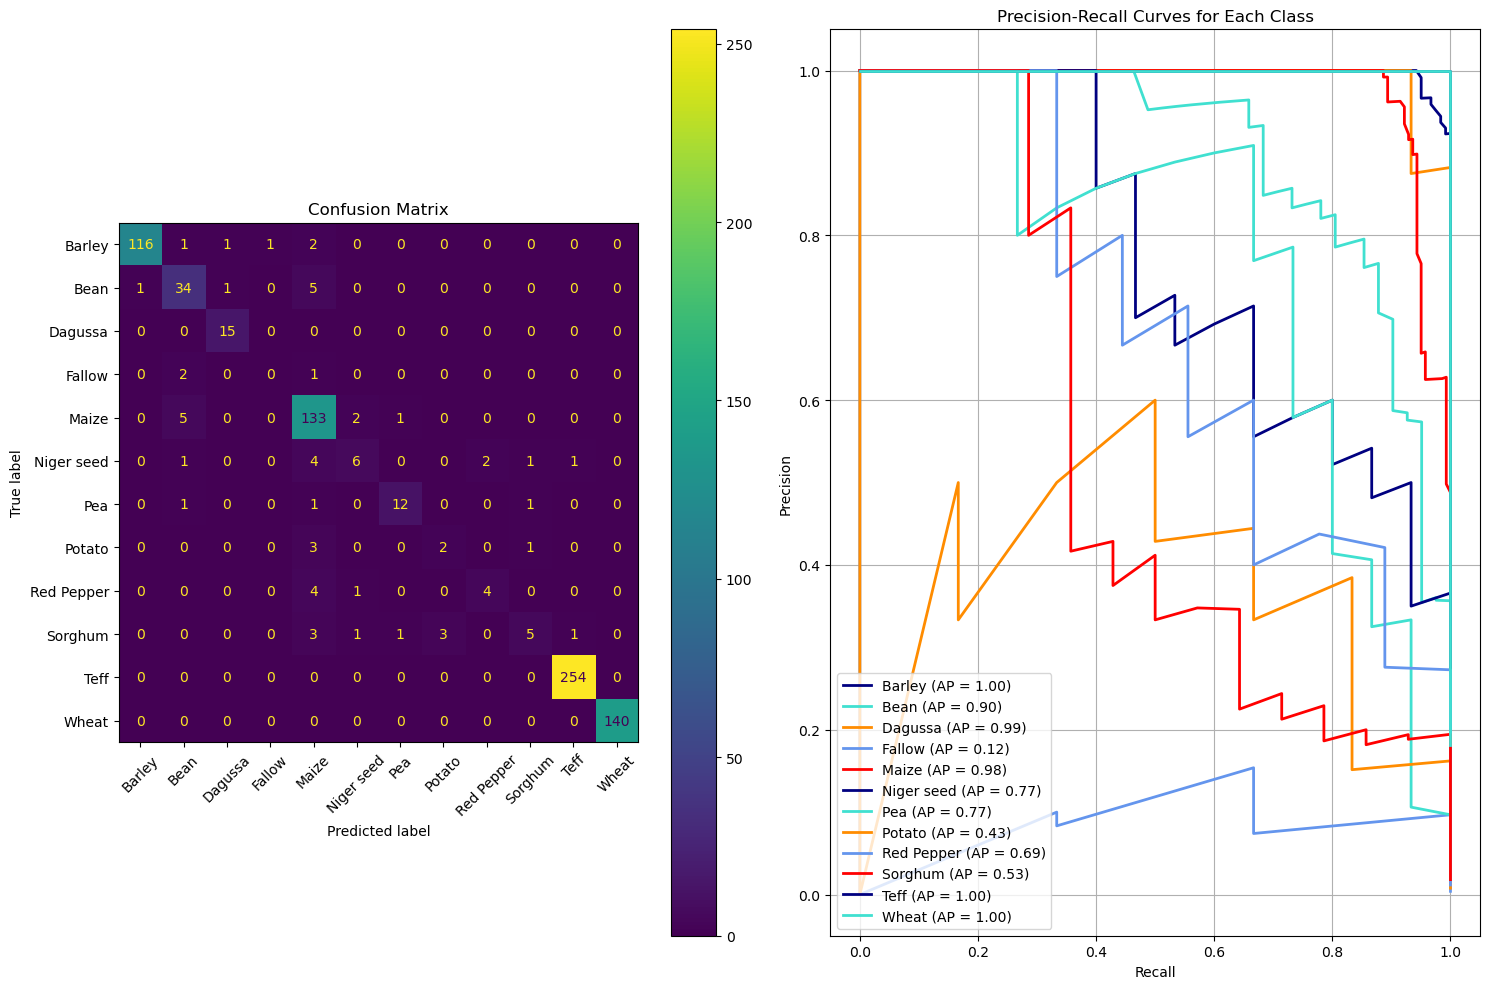

In [19]:
plt.figure(figsize=(15, 10))

# Create subplot layout
plt.subplot(1, 2, 1)

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder_label.classes_
)
disp.plot(ax=plt.gca(), xticks_rotation=45)
plt.title('Confusion Matrix')

# Calculate and plot Precision-Recall curves
plt.subplot(1, 2, 2)
y_pred_proba = model.predict_proba(X_test)

# Compute precision-recall curves for each class
n_classes = len(np.unique(y))
precision = dict()
recall = dict()
avg_precision = dict()

colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'red'])

for i, color in zip(range(n_classes), colors):
    # For each class, calculate precision and recall
    precision[i], recall[i], _ = precision_recall_curve(
        (y_test == i).astype(int),
        y_pred_proba[:, i]
    )
    avg_precision[i] = average_precision_score(
        (y_test == i).astype(int),
        y_pred_proba[:, i]
    )
    
    # Plot precision-recall curve for each class
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'{label_encoder_label.classes_[i]} (AP = {avg_precision[i]:0.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Each Class')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()

# Print detailed evaluation metrics
print("\nDetailed Classification Metrics:")
print("================================")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# Calculate and print weighted average precision
weighted_avg_precision = np.average(
    list(avg_precision.values()),
    weights=[np.sum(y_test == i) for i in range(n_classes)]
)
print(f"\nWeighted Average Precision: {weighted_avg_precision:.2f}")

print("\nPer-class Average Precision:")
for i in range(n_classes):
    print(f"{label_encoder_label.classes_[i]}: {avg_precision[i]:.2f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder_label.classes_))

plt.show()

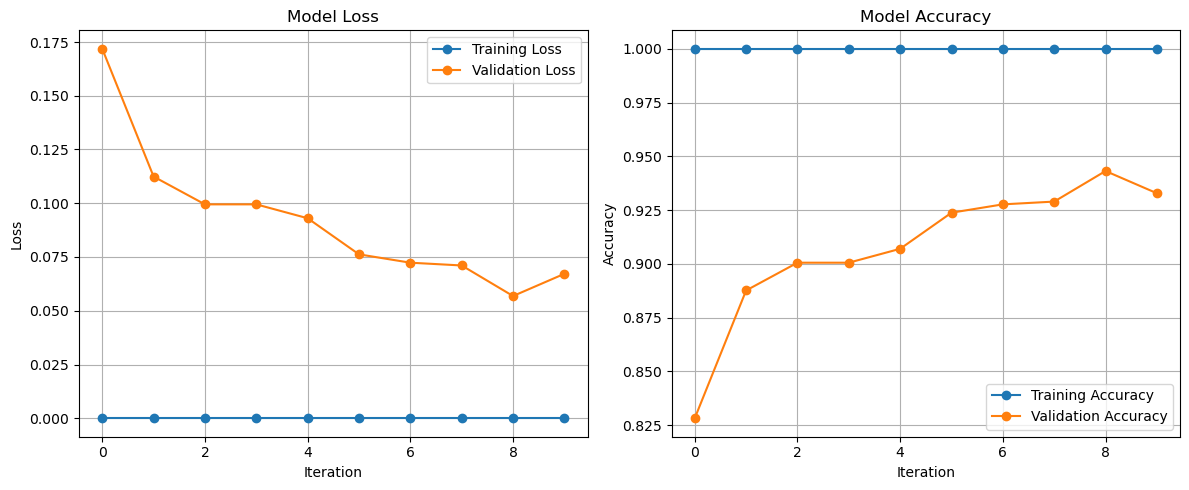


Final Training Accuracy: 1.0
Final Validation Accuracy: 0.9328165374677002

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       121
           1       0.76      0.85      0.80        41
           2       0.93      0.93      0.93        15
           3       0.00      0.00      0.00         3
           4       0.85      0.94      0.89       141
           5       0.73      0.53      0.62        15
           6       0.79      0.73      0.76        15
           7       0.40      0.33      0.36         6
           8       0.80      0.44      0.57         9
           9       0.62      0.36      0.45        14
          10       1.00      1.00      1.00       254
          11       1.00      1.00      1.00       140

    accuracy                           0.93       774
   macro avg       0.74      0.67      0.70       774
weighted avg       0.93      0.93      0.93       774



In [21]:
def train_with_validation(X_train, X_test, y_train, y_test, n_iterations=10):
    # Convert to numpy arrays if they're pandas objects
    if isinstance(X_train, pd.DataFrame):
        X_train = X_train.to_numpy()
    if isinstance(X_test, pd.DataFrame):
        X_test = X_test.to_numpy()
    if isinstance(y_train, pd.Series):
        y_train = y_train.to_numpy()
    if isinstance(y_test, pd.Series):
        y_test = y_test.to_numpy()
    
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    # Initialize model
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42
    )
    
    # Train incrementally to simulate epochs
    subset_sizes = np.linspace(0.1, 1.0, n_iterations)
    
    for size in subset_sizes:
        # Take a subset of training data
        subset_size = int(len(X_train) * size)
        indices = np.random.choice(len(X_train), subset_size, replace=False)
        X_subset = X_train[indices]
        y_subset = y_train[indices]
        
        # Train model
        model.fit(X_subset, y_subset)
        
        # Calculate training metrics
        train_pred = model.predict(X_subset)
        train_acc = accuracy_score(y_subset, train_pred)
        train_loss = 1 - train_acc  # Using error rate as proxy for loss
        
        # Calculate validation metrics
        val_pred = model.predict(X_test)
        val_acc = accuracy_score(y_test, val_pred)
        val_loss = 1 - val_acc
        
        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
    
    return model, {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }

# Train model with history
model, history = train_with_validation(X_train, X_test, y_train, y_test)

# Create the visualization
plt.figure(figsize=(12, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Accuracy:", history['train_acc'][-1])
print("Final Validation Accuracy:", history['val_acc'][-1])

# Print classification report
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))